# 02 Feature Engineering

In [7]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, os.path.abspath('..'))

from src.data.preprocessing import load_data, preprocess
from src.features.engineering import FEATURE_COLS, build_features

PROJECT_ROOT = Path('..').resolve()
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'

raw_training_data, raw_testing_data = load_data(
    RAW_DATA_DIR / 'train.csv', RAW_DATA_DIR / 'test.csv'
)

print(f'Train dataset shape: {raw_training_data.shape}')
print(f'Test dataset shape: {raw_testing_data.shape}')

Train dataset shape: (577347, 12)
Test dataset shape: (247435, 11)


In [8]:
# Data preprocessing
processed_training_data = preprocess(raw_training_data)
processed_testing_data = preprocess(raw_testing_data)

# Feature engineering
engineered_training_features = build_features(processed_training_data)
engineered_testing_features = build_features(processed_testing_data)

print(f'Train dataset after feature engineering: {engineered_training_features.shape}')
print(f'Test dataset after feature engineering: {engineered_testing_features.shape}')
print('\nNew columns added:')

newly_added_columns = [
    column_name
    for column_name in engineered_training_features.columns
    if column_name not in raw_training_data.columns
]
print(newly_added_columns)

Train dataset after feature engineering: (577347, 55)
Test dataset after feature engineering: (247435, 54)

New columns added:
['spectral_type_enc', 'galaxy_population_enc', 'u_g', 'g_r', 'r_i', 'i_z', 'g_i', 'r_z', 'u_r', 'g_z', 'u_i', 'u_z', 'r_g', 'g_div_z', 'r_div_i', 'u_div_r', 'g_div_r', 'gz_x_ri', 'gr_x_iz', 'band_mean', 'band_std', 'band_min', 'band_max', 'band_range', 'band_sum', 'band_skew', 'band_median', 'band_iqr', 'band_cv', 'redshift_log1p', 'redshift_sq', 'redshift_sqrt', 'redshift_abs', 'is_high_z', 'is_star_z', 'is_redshift_zero', 'is_very_high_z', 'is_negative_z', 'redshift_x_gz', 'redshift_x_bandstd', 'redshift_x_bandmean', 'redshift_over_bandmean', 'g_r_x_redshift', 'u_g_x_redshift', 'delta_abs']


In [9]:
# Verify required features and nulls
missing_feature_columns = [
    column_name
    for column_name in FEATURE_COLS
    if column_name not in engineered_training_features.columns
]
print(f'Missing features: {missing_feature_columns if missing_feature_columns else "None"}')

missing_value_counts = engineered_training_features[FEATURE_COLS].isnull().sum()
print('\nNull check:')
print(
    missing_value_counts[missing_value_counts > 0]
    if missing_value_counts.any()
    else 'No nulls in any feature column'
)

feature_summary = engineered_training_features[FEATURE_COLS].describe().T
print(feature_summary[["mean", "std", "min", "max"]])

Missing features: None

Null check:
No nulls in any feature column
                              mean        std           min         max
alpha                   181.616673  96.242941  1.168375e-02  359.999810
delta                    21.834654  18.933570 -1.796699e+01   79.158322
delta_abs                22.796887  17.763280  4.005739e-06   79.158322
u                        22.441926   2.018135 -1.392249e-01   28.253263
g                        21.007273   1.795426  1.353548e+01   27.620208
r                        19.962811   1.648964  1.257941e+01   25.254499
i                        19.378911   1.580059  1.196278e+01   27.910853
z                        19.041136   1.584365  1.168280e+01   26.826867
redshift                  0.723135   0.810070 -9.970358e-03    7.010780
u_g                       1.434652   1.142003 -2.315586e+01    7.523080
g_r                       1.044463   0.736291 -8.104372e+00    8.874428
r_i                       0.583900   0.496787 -1.075796e+01    8.7493

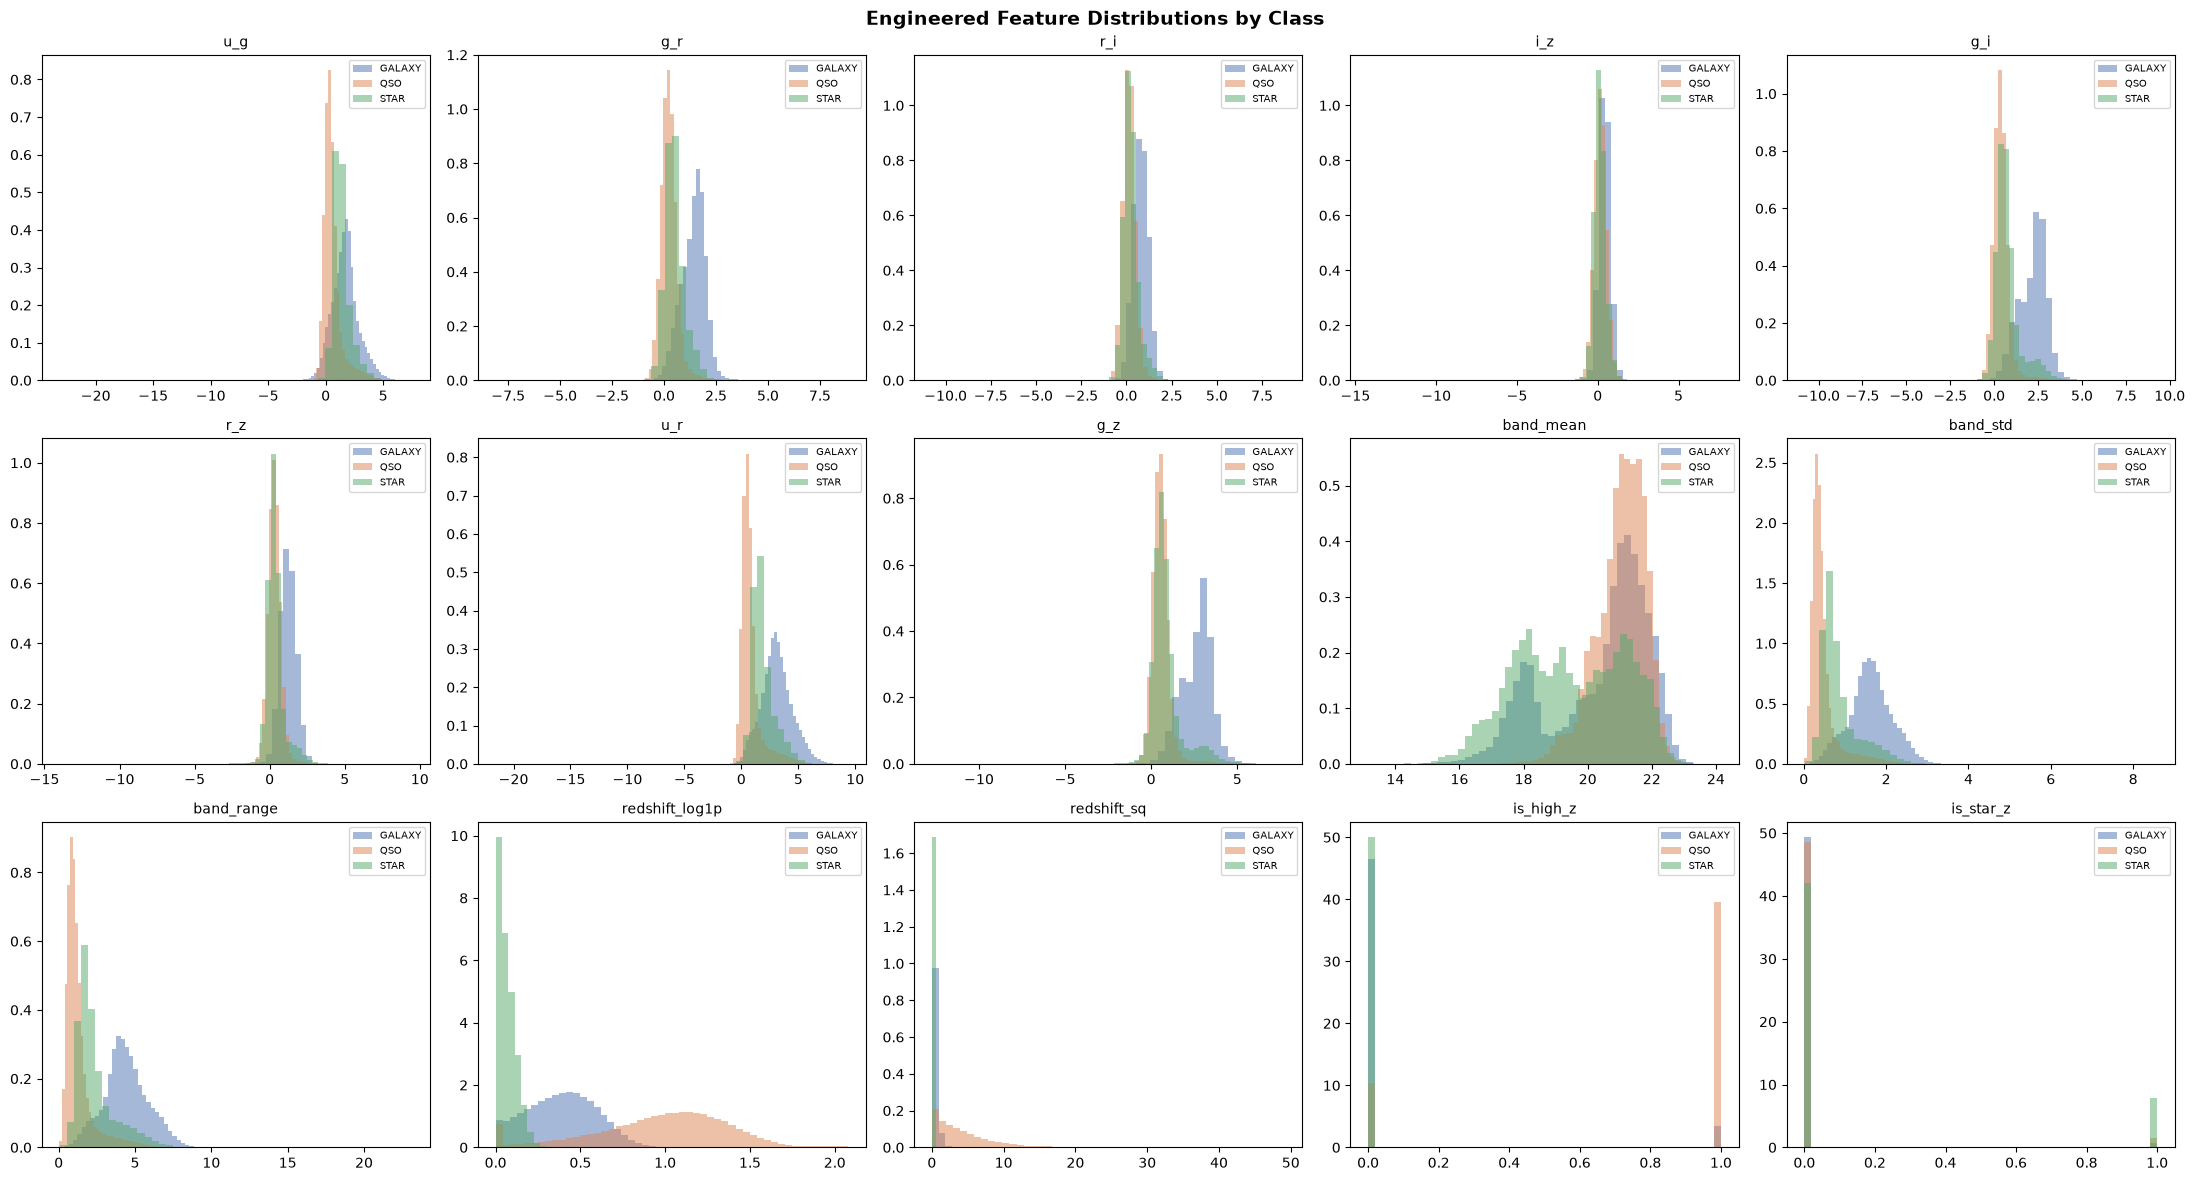

Chart saved successfully.


In [10]:
newly_engineered_features = [
    'u_g', 'g_r', 'r_i', 'i_z', 'g_i', 'r_z', 'u_r', 'g_z',
    'band_mean', 'band_std', 'band_range', 'redshift_log1p',
    'redshift_sq', 'is_high_z', 'is_star_z',
]

target_classes = ['GALAXY', 'QSO', 'STAR']
visualization_colors = ['#4C72B0', '#DD8452', '#55A868']

figure, axes = plt.subplots(3, 5, figsize=(22, 12))
flattened_axes = axes.flatten()

for feature_index, feature_name in enumerate(newly_engineered_features):
    for class_name, color_code in zip(target_classes, visualization_colors):
        class_subset = engineered_training_features[
            engineered_training_features['class'] == class_name
        ][feature_name]
        flattened_axes[feature_index].hist(
            class_subset,
            bins=50,
            alpha=0.5,
            label=class_name,
            color=color_code,
            density=True,
        )
    flattened_axes[feature_index].set_title(feature_name, fontsize=10)
    flattened_axes[feature_index].legend(fontsize=7)

plt.suptitle(
    'Engineered Feature Distributions by Class',
    fontsize=14,
    fontweight='bold',
)
plt.tight_layout()
plt.savefig('../outputs/eda_engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

print('Chart saved successfully.')

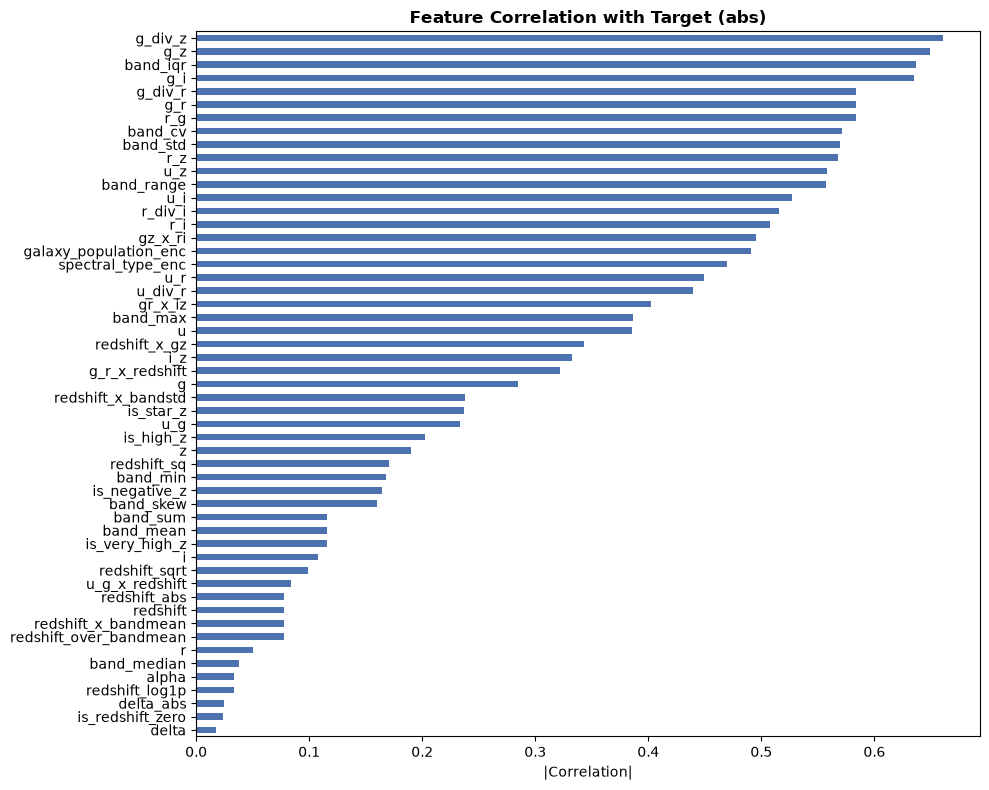


Top 10 features by correlation:
g_div_z     0.660424
g_z         0.649074
band_iqr    0.636526
g_i         0.635034
g_div_r     0.584032
g_r         0.583357
r_g         0.583357
band_cv     0.571801
band_std    0.569432
r_z         0.567993
Name: class_enc, dtype: float64


In [11]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
engineered_training_features['class_enc'] = label_encoder.fit_transform(
    engineered_training_features['class']
)

target_correlations = (
    engineered_training_features[FEATURE_COLS + ['class_enc']]
    .corr()['class_enc']
    .drop('class_enc')
)
sorted_absolute_correlations = target_correlations.abs().sort_values(
    ascending=False
)

plt.figure(figsize=(10, 8))
sorted_absolute_correlations.plot(kind='barh', color='#4C72B0')
plt.title('Feature Correlation with Target (abs)', fontweight='bold')
plt.xlabel('|Correlation|')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/feature_importance_corr.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 features by correlation:')
print(sorted_absolute_correlations.head(10))

In [12]:
import os
import sys
import json
import logging
from pathlib import Path

sys.path.insert(0, os.path.abspath('..'))

# ─────────────────────────────────────────────
#  LOGGING + DATA VALIDATION
# ─────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)-8s | %(name)s | %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger(__name__)

from src.exceptions import DataDriftException
from src.models.train import run_adversarial_validation

PROJECT_ROOT = Path('..').resolve()
DATA_PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'

DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

logger.info(f'Project root: {PROJECT_ROOT}')
logger.info(f'Processed data directory: {DATA_PROCESSED_DIR}')
logger.info(f'Outputs directory: {OUTPUTS_DIR}')

available_feature_columns = [
    column_name
    for column_name in FEATURE_COLS
    if column_name in engineered_training_features.columns
]
missing_feature_columns = [
    column_name
    for column_name in FEATURE_COLS
    if column_name not in engineered_training_features.columns
]

if missing_feature_columns:
    logger.error(f'Missing features after engineering: {missing_feature_columns}')
    raise ValueError(
        f'Missing features after engineering: {missing_feature_columns}'
    )

logger.info(f'Feature validation passed: {len(available_feature_columns)} features verified')

final_training_features = (
    engineered_training_features[available_feature_columns]
    .copy()
    .reindex(columns=available_feature_columns, fill_value=0.0)
)
final_training_target = engineered_training_features[['class']].copy()
final_testing_features = (
    engineered_testing_features[available_feature_columns]
    .copy()
    .reindex(columns=available_feature_columns, fill_value=0.0)
)

logger.info('\n' + '='*70)
logger.info('STARTING ADVERSARIAL VALIDATION (Data Distribution Quality Gate)')
logger.info('='*70)

AUC_DRIFT_THRESHOLD = 0.70

try:
    adv_validation_result = run_adversarial_validation(
        final_training_features, final_testing_features,
        n_splits=5, threshold=AUC_DRIFT_THRESHOLD
    )

    roc_auc_score = adv_validation_result['roc_auc']
    feature_drift_df = adv_validation_result['feature_importances']
    is_drifted = adv_validation_result['is_drifted']

    logger.info('\n✓ Adversarial Validation completed')
    logger.info(f'  ROC-AUC Score: {roc_auc_score:.4f}')
    logger.info(f'  Threshold: {AUC_DRIFT_THRESHOLD:.4f}')
    logger.info(f'  Distribution Shift Detected: {is_drifted}')

    if is_drifted:
        logger.error('\n' + '!'*70)
        logger.error('CRITICAL: DATA DRIFT DETECTED - QUALITY GATE FAILED')
        logger.error('!'*70)
        raise DataDriftException(
            roc_auc=roc_auc_score,
            threshold=AUC_DRIFT_THRESHOLD,
            feature_importance_df=feature_drift_df
        )

    logger.info('\n' + '✓'*70)
    logger.info('✓ DATA DISTRIBUTION QUALITY GATE PASSED')
    logger.info('✓ Saving processed datasets...')

    final_training_features.to_csv(DATA_PROCESSED_DIR / 'X_train.csv', index=False)
    final_training_target.to_csv(DATA_PROCESSED_DIR / 'y_train.csv', index=False)
    final_testing_features.to_csv(DATA_PROCESSED_DIR / 'X_test.csv', index=False)
    pd.Series(available_feature_columns).to_csv(
        DATA_PROCESSED_DIR / 'feature_columns.csv', index=False, header=['feature']
    )

    logger.info(f'✓ X_train saved: {final_training_features.shape}')
    logger.info(f'✓ y_train saved: {final_training_target.shape}')
    logger.info(f'✓ X_test saved: {final_testing_features.shape}')
    logger.info(f'✓ Feature columns saved: {len(available_feature_columns)} features')

    report_data = {
        'adversarial_validation': {
            'roc_auc_score': float(roc_auc_score),
            'threshold': float(AUC_DRIFT_THRESHOLD),
            'distribution_shift_detected': bool(is_drifted),
            'n_train_samples': len(final_training_features),
            'n_test_samples': len(final_testing_features),
            'n_features': len(available_feature_columns),
        },
        'top_10_drifted_features': feature_drift_df.head(10).to_dict(orient='records'),
        'status': 'PASSED',
    }
    report_path = OUTPUTS_DIR / 'adversarial_validation_report.json'
    with open(report_path, 'w', encoding='utf-8') as f:
        json.dump(report_data, f, indent=2)
    logger.info(f'✓ Adversarial validation report saved to: {report_path}')

except DataDriftException:
    logger.critical('Pipeline halted due to data drift. No processed datasets were saved.')
    raise
except Exception as e:
    logger.error(f'Unexpected error during adversarial validation: {e}', exc_info=True)
    raise

2026-07-26 12:42:25 | INFO     | __main__ | Project root: D:\Dev\predicting-stellar-class
2026-07-26 12:42:25 | INFO     | __main__ | Processed data directory: D:\Dev\predicting-stellar-class\data\processed
2026-07-26 12:42:25 | INFO     | __main__ | Outputs directory: D:\Dev\predicting-stellar-class\outputs
2026-07-26 12:42:25 | INFO     | __main__ | Feature validation passed: 53 features verified
2026-07-26 12:42:25 | INFO     | __main__ | 
2026-07-26 12:42:25 | INFO     | __main__ | STARTING ADVERSARIAL VALIDATION (Data Distribution Quality Gate)
2026-07-26 12:42:25 | INFO     | __main__ | ======================================================================
12:42:25 | INFO     | Running Adversarial Validation | Train: 577,347 | Test: 247,435
2026-07-26 12:42:25 | INFO     | stellar | Running Adversarial Validation | Train: 577,347 | Test: 247,435
12:42:25 | INFO     | Drift Threshold: 0.7000
2026-07-26 12:42:25 | INFO     | stellar | Drift Threshold: 0.7000
12:42:27 | INFO     | F